<a href="https://colab.research.google.com/github/aliceczr/SIFA-LSTM/blob/main/LSTM_SIFA26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install pysus
!pip install pandas
!pip install tensorflow
!pip install keras
!pip install sklearn
!pip install numpy
!pip install matplotlib
!pip install seaborn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
import random
random.seed(42)

import numpy as np
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)

In [3]:
#from pysus import sinan
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


##Extração e exploração de dados

In [4]:
usuario = 'aliceczr'
repositorio = 'SIFA-LSTM'
pasta = 'data'

api_url = f"https://api.github.com/repos/{usuario}/{repositorio}/contents/{pasta}"
response = requests.get(api_url)
dados_api = response.json()

dic_sifas = {}

for item in dados_api:
  nome_arquivo = item['name']
  link_raw = item['download_url']
  print(f'Baixando:{nome_arquivo}')
  nome_limpo = nome_arquivo.replace('.csv', '')
  dic_sifas[nome_limpo] = pd.read_csv(link_raw)


Baixando:sifa_14.csv
Baixando:sifa_15.csv
Baixando:sifa_16.csv
Baixando:sifa_17.csv
Baixando:sifa_18.csv
Baixando:sifa_19.csv


/tmp/ipykernel_2200/1811678959.py:16: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  dic_sifas[nome_limpo] = pd.read_csv(link_raw)


Baixando:sifa_20.csv
Baixando:sifa_21.csv
Baixando:sifa_22.csv
Baixando:sifa_23.csv
Baixando:sifa_24.csv


##Pré-processamento


In [5]:
import pandas as pd

df_completo = pd.DataFrame()
for nome_df in dic_sifas.keys():
      df_to_modify = dic_sifas[nome_df]
      coluna_numerica = pd.to_numeric(df_to_modify['CLASSI_FIN'], errors='coerce')
      filtered_mask = coluna_numerica == 1
      df_filtered = df_to_modify[filtered_mask].copy()

      if not df_filtered.empty:
          df_filtered['DT_DIAG'] = pd.to_datetime(df_filtered['DT_DIAG'], format='%Y%m%d', errors='coerce')
          df_filtered = df_filtered[df_filtered['DT_DIAG'].dt.year < 2024]

          dic_sifas[nome_df] = df_filtered[['DT_DIAG', 'CLASSI_FIN']]
          df_completo = pd.concat([df_completo, df_filtered[['DT_DIAG', 'CLASSI_FIN']]], ignore_index=True)


In [6]:
df_completo['CONTAGEM'] = 1
df_completo.set_index('DT_DIAG', inplace=True)

serie_diaria = df_completo['CONTAGEM'].resample('D').sum()

serie_semanal = df_completo['CONTAGEM'].resample('W').sum()

In [7]:
def criar_janela(dados, window_input, window_output):
    X, y = [], []
    for i in range(len(dados) - window_input - window_output + 1):
      janela_entrada = dados[i : i + window_input]
      janela_saida = dados[i + window_input : i + window_input + window_output]
      X.append(janela_entrada)
      y.append(janela_saida)
    return np.array(X), np.array(y)

In [8]:
def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

##Modelo Diário



In [9]:
total = len(serie_diaria)
idx1  = int(total * 0.90)
idx2  = int(total * 0.95)

train_data = serie_diaria[:idx1]
val_data   = serie_diaria[idx1:idx2]
test_data  = serie_diaria[idx2:]


In [10]:
scaler = MinMaxScaler(feature_range=(0, 1))
treino_norm = scaler.fit_transform(train_data.values.reshape(-1, 1))
val_norm    = scaler.transform(val_data.values.reshape(-1, 1))
teste_norm  = scaler.transform(test_data.values.reshape(-1, 1))

In [11]:
X_train, y_train = criar_janela(treino_norm, 20, 7)
X_val,   y_val   = criar_janela(val_norm,   20, 7)
X_test,  y_test  = criar_janela(teste_norm, 20, 7)

In [12]:
X_train = X_train.reshape(X_train.shape[0], 20, 1)
X_val   = X_val.reshape(X_val.shape[0],   20, 1)
X_test  = X_test.reshape(X_test.shape[0], 20, 1)

In [13]:
opt = keras.optimizers.RMSprop(learning_rate=1e-4, momentum=0.9)


In [14]:
model_d = Sequential([
    LSTM(50, input_shape=(20, 1)),
    Dropout(0.2),
    Dense(7)
])
model_d.compile(optimizer=opt, loss=rmse)
model_d.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,757 (42.02 KB)

 Trainable params: 10,757 (42.02 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
out = model_d.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=16,
    verbose=1
)

Epoch 1/150
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.1620 - val_loss: 0.3342
Epoch 2/150
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1412 - val_loss: 0.2981
Epoch 3/150
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1133 - val_loss: 0.2469
Epoch 4/150
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1058 - val_loss: 0.2407
Epoch 5/150
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1034 - val_loss: 0.2375
Epoch 6/150
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1018 - val_loss: 0.2328
Epoch 7/150
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1015 - val_loss: 0.2318
Epoch 8/150
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1002 - val_loss: 0.2295
Epoch 9/150
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0993 - val_loss: 0.2219
Epoch 10/150
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0984 - val_loss: 0.2196
Epoch 11/150
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0970 - val_loss: 0.2147
Epoch 12/150
286/286 ━━━━━━━━━━━━━━━━━

###Modelo Semanal

In [16]:
total = len(serie_semanal)
idx1_s  = int(total* 0.85)
idx2_s = int(total* 0.92)

train_data_s = serie_semanal[:idx1_s]
val_data_s   = serie_semanal[idx1_s:idx2_s]
test_data_s = serie_semanal[idx2_s:]

In [17]:
serie_semanal_suavizada = serie_semanal.rolling(window=3, min_periods=1).mean()

train_data_s_mv = serie_semanal_suavizada[:idx1_s]
val_data_s_mv   = serie_semanal_suavizada[idx1_s:idx2_s]
test_data_s_mv  = serie_semanal_suavizada[idx2_s:]

In [18]:
scaler_w = MinMaxScaler(feature_range=(0,1))
treino_norm_w = scaler_w.fit_transform(train_data_s.values.reshape(-1, 1))
val_norm_w    = scaler_w.transform(val_data_s.values.reshape(-1, 1))
teste_norm_w  = scaler_w.transform(test_data_s.values.reshape(-1, 1))

In [19]:
X_train_s, y_train_s = criar_janela(treino_norm_w, 3, 1)
X_val_s,   y_val_s   = criar_janela(val_norm_w,   3, 1)
X_test_s,  y_test_s  = criar_janela(teste_norm_w, 3, 1)

In [20]:
X_train_s = X_train_s.reshape(X_train_s.shape[0], 3, 1)
X_val_s  = X_val_s.reshape(X_val_s.shape[0],   3, 1)
X_test_s = X_test_s.reshape(X_test_s.shape[0], 3, 1)

In [21]:

opt_s = keras.optimizers.RMSprop(learning_rate=1e-4, momentum=0.9)
model_s = Sequential([
    LSTM(256, input_shape=(3, 1)),
    Dropout(0.2),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
model_s.compile(optimizer=opt_s, loss=rmse)
model_s.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 256)            │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,449 (1.01 MB)

 Trainable params: 264,449 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
out_sem = model_s.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=150,
    batch_size=16,
    verbose=1
)

Epoch 1/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1905 - val_loss: 0.1473
Epoch 2/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0746 - val_loss: 0.1438
Epoch 3/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0730 - val_loss: 0.1474
Epoch 4/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0720 - val_loss: 0.1434
Epoch 5/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0729 - val_loss: 0.1435
Epoch 6/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0721 - val_loss: 0.1431
Epoch 7/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0740 - val_loss: 0.1444
Epoch 8/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0753 - val_loss: 0.1429
Epoch 9/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0740 - val_loss: 0.1432
Epoch 10/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0715 - val_loss: 0.1414
Epoch 11/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0715 - val_loss: 0.1413
Epoch 12/150
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

###Visualização

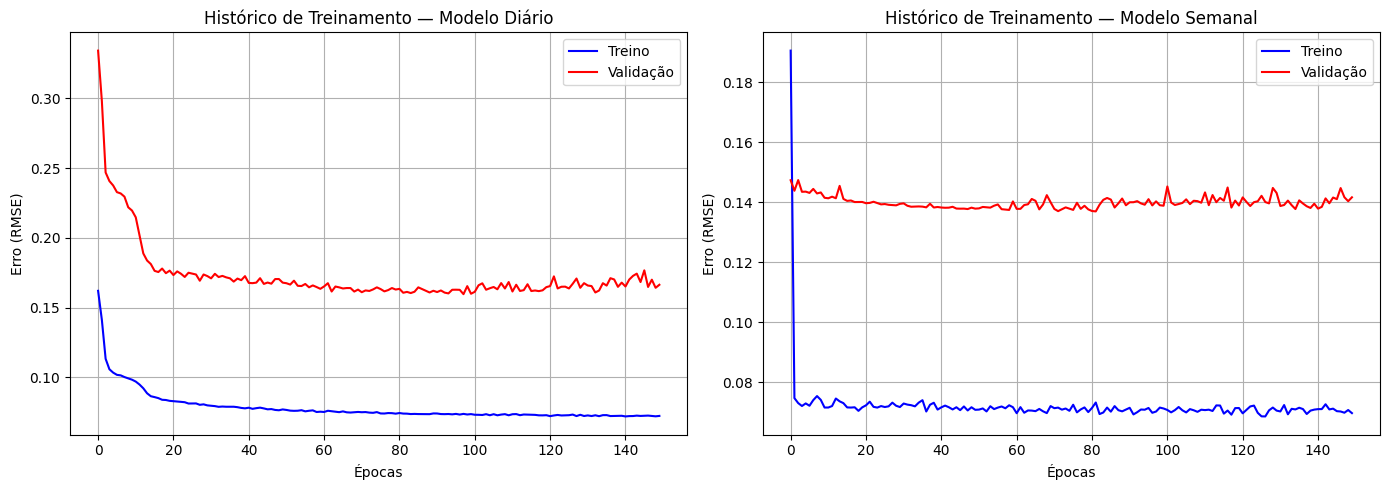

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(out.history['loss'],     label='Treino',     color='blue')
ax1.plot(out.history['val_loss'], label='Validação',  color='red')
ax1.set_title('Histórico de Treinamento — Modelo Diário')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Erro (RMSE)')
ax1.legend()
ax1.grid(True)

ax2.plot(out_sem.history['loss'],     label='Treino',    color='blue')
ax2.plot(out_sem.history['val_loss'], label='Validação', color='red')
ax2.set_title('Histórico de Treinamento — Modelo Semanal')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Erro (RMSE)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('historico_treinamento.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
predict   = model_d.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [26]:
y_test_inv  = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, 7)
predict_inv = scaler.inverse_transform(predict.reshape(-1, 1)).reshape(-1, 7)


In [27]:
rmse_original = np.sqrt(np.mean((y_test_inv - predict_inv) ** 2))
media_original = np.mean(y_test_inv)
nrmse = (rmse_original / media_original) * 100

print(f"\n[Diário] Média do conjunto de teste: {media_original:.2f}")
print(f"[Diário] RMSE (escala real):         {rmse_original:.2f}")
print(f"[Diário] NRMSE:                      {nrmse:.1f}%")


[Diário] Média do conjunto de teste: 549.73
[Diário] RMSE (escala real):         136.21
[Diário] NRMSE:                      24.8%


In [28]:
rmse_por_dia = []
corr_por_dia = []
p_value      = []

for dia in range(7):
    real = y_test_inv[:, dia].flatten()
    prev = predict_inv[:, dia].flatten()
    rmse_d  = np.sqrt(np.mean((real - prev) ** 2))
    r, p_val = stats.pearsonr(real, prev)
    rmse_por_dia.append(rmse_d)
    corr_por_dia.append(r)
    p_value.append(p_val)

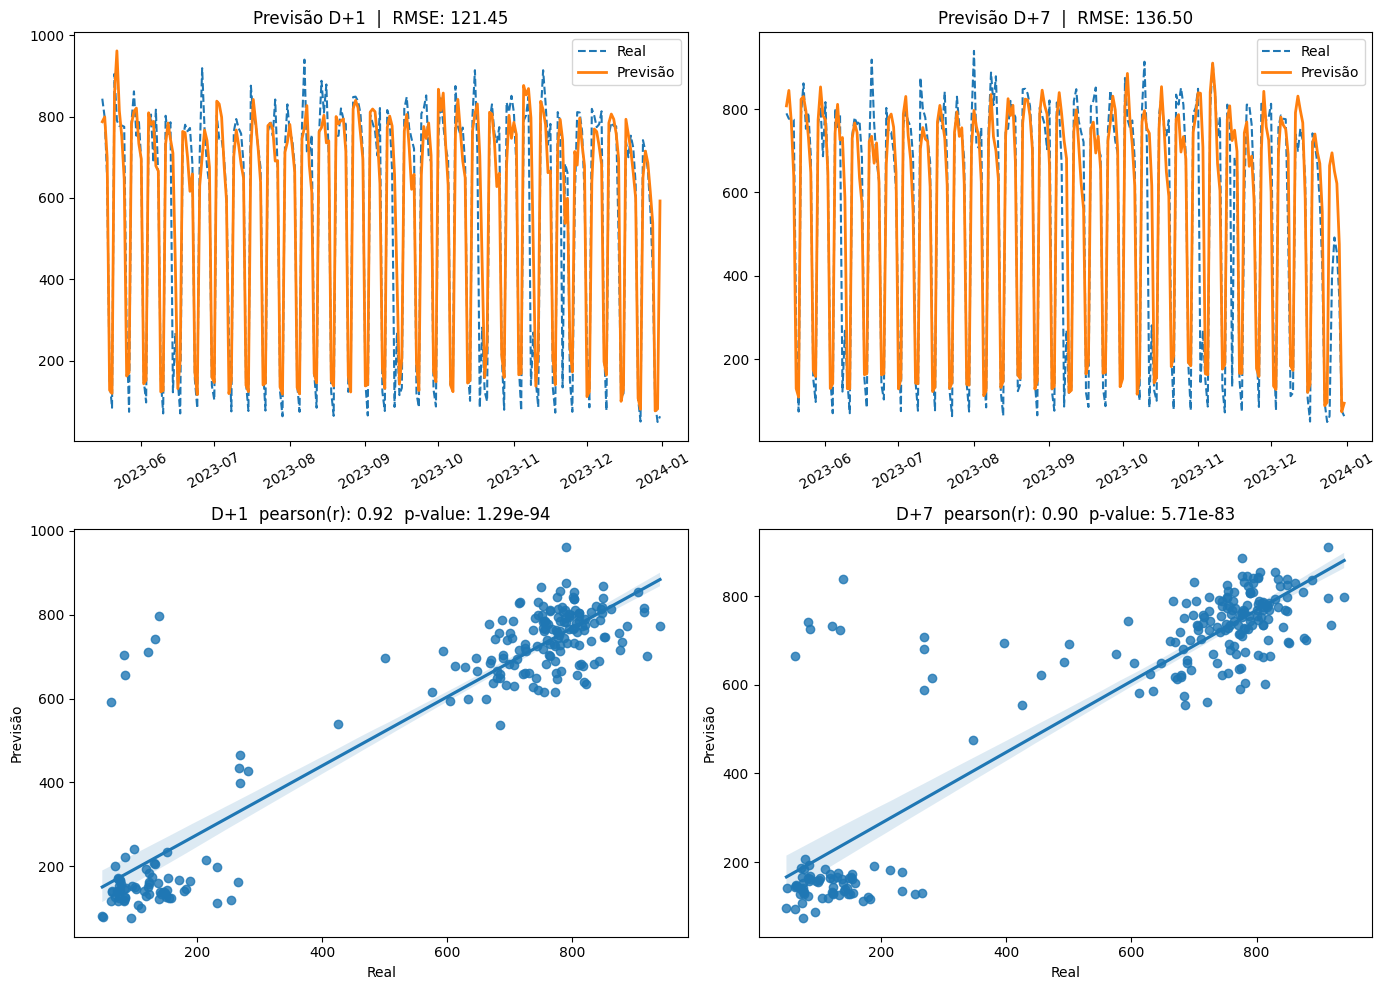

In [29]:
n_plot = len(y_test_inv)
teste_date = test_data.index[-n_plot:].to_pydatetime()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

ax1.plot(teste_date, y_test_inv[:, 0], label='Real',    linestyle='--')
ax1.plot(teste_date, predict_inv[:, 0], label='Previsão', linewidth=2)
ax1.tick_params(axis='x', rotation=30)
ax1.set_title(f'Previsão D+1  |  RMSE: {rmse_por_dia[0]:.2f}')
ax1.legend()

ax2.plot(teste_date, y_test_inv[:, 6], label='Real',    linestyle='--')
ax2.plot(teste_date, predict_inv[:, 6], label='Previsão', linewidth=2)
ax2.tick_params(axis='x', rotation=30)
ax2.set_title(f'Previsão D+7  |  RMSE: {rmse_por_dia[6]:.2f}')
ax2.legend()

sns.regplot(x=y_test_inv[:, 0], y=predict_inv[:, 0], ax=ax3)
ax3.set_xlabel('Real')
ax3.set_ylabel('Previsão')
ax3.set_title(f'D+1  pearson(r): {corr_por_dia[0]:.2f}  p-value: {p_value[0]:.2e}')

sns.regplot(x=y_test_inv[:, 6], y=predict_inv[:, 6], ax=ax4)
ax4.set_xlabel('Real')
ax4.set_ylabel('Previsão')
ax4.set_title(f'D+7  pearson(r): {corr_por_dia[6]:.2f}  p-value: {p_value[6]:.2e}')

plt.tight_layout()
plt.savefig('previsao_diaria.png', dpi=150, bbox_inches='tight')
plt.show()

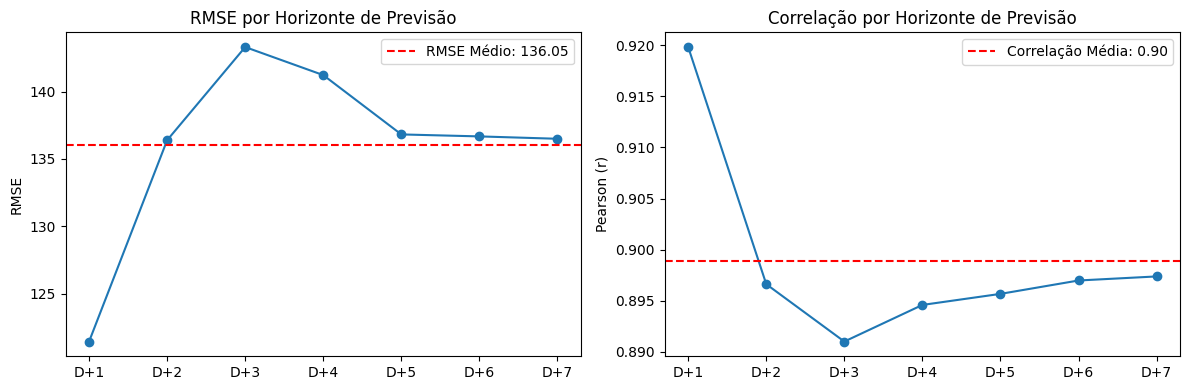

In [30]:
rmse_med_dia = np.mean(rmse_por_dia)
corr_med_dia = np.mean(corr_por_dia)
dias_labels  = ['D+1', 'D+2', 'D+3', 'D+4', 'D+5', 'D+6', 'D+7']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(dias_labels, rmse_por_dia, marker='o')
ax1.axhline(y=rmse_med_dia, color='r', linestyle='--', label=f'RMSE Médio: {rmse_med_dia:.2f}')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE por Horizonte de Previsão')
ax1.legend()

ax2.plot(dias_labels, corr_por_dia, marker='o')
ax2.axhline(y=corr_med_dia, color='r', linestyle='--', label=f'Correlação Média: {corr_med_dia:.2f}')
ax2.set_title('Correlação por Horizonte de Previsão')
ax2.set_ylabel('Pearson (r)')
ax2.legend()

plt.tight_layout()
plt.savefig('rmse_correlacao_diario.png', dpi=150, bbox_inches='tight')
plt.show()


In [31]:
predict_s = model_s.predict(X_test_s)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


In [32]:
scaler_w_real      = MinMaxScaler(feature_range=(0, 1))
treino_real_w      = scaler_w_real.fit_transform(train_data_s.values.reshape(-1, 1))
val_real_w         = scaler_w_real.transform(val_data_s.values.reshape(-1, 1))
teste_real_w       = scaler_w_real.transform(test_data_s.values.reshape(-1, 1))


In [33]:
predict_inv_s = scaler_w.inverse_transform(predict_s.reshape(-1, 1)).reshape(predict_s.shape)
y_test_inv_s  = scaler_w.inverse_transform(y_test_s.reshape(-1, 1)).reshape(y_test_s.shape)



In [34]:
rmse_original_s  = np.sqrt(np.mean((y_test_inv_s - predict_inv_s) ** 2))
media_original_s = np.mean(y_test_inv_s)
nrmse_s          = (rmse_original_s / media_original_s) * 100

print(f"\n[Semanal] Média do conjunto de teste: {media_original_s:.2f}")
print(f"[Semanal] RMSE (escala real):         {rmse_original_s:.2f}")
print(f"[Semanal] NRMSE:                      {nrmse_s:.1f}%")


[Semanal] Média do conjunto de teste: 3895.04
[Semanal] RMSE (escala real):         601.60
[Semanal] NRMSE:                      15.4%


In [35]:
real_s   = y_test_inv_s.flatten()
prev_s   = predict_inv_s.flatten()
r_s, p_s = stats.pearsonr(real_s, prev_s)

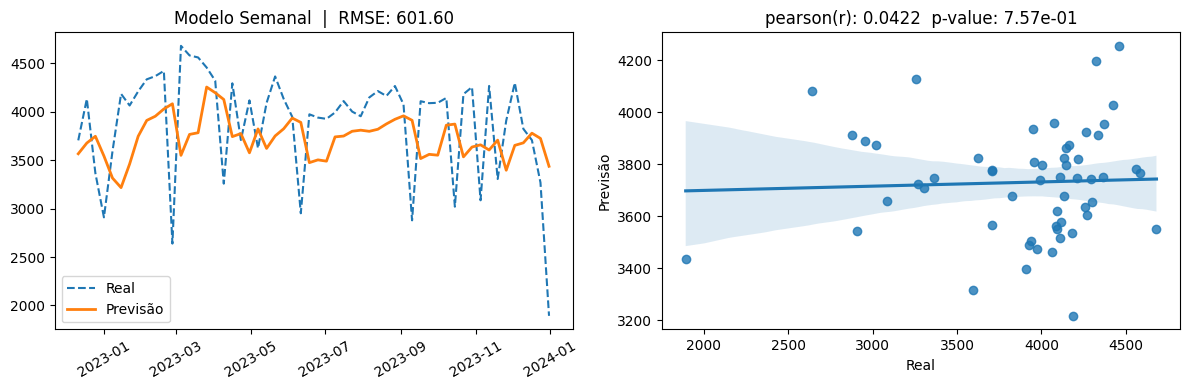

In [36]:
n_plot_s     = len(y_test_inv_s)
teste_date_s = test_data_s.index[-n_plot_s:].to_pydatetime()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(teste_date_s, y_test_inv_s[:, 0], label='Real',    linestyle='--')
ax1.plot(teste_date_s, predict_inv_s[:, 0], label='Previsão', linewidth=2)
ax1.set_title(f'Modelo Semanal  |  RMSE: {rmse_original_s:.2f}')
ax1.tick_params(axis='x', rotation=30)
ax1.legend()

sns.regplot(x=y_test_inv_s[:, 0], y=predict_inv_s[:, 0], ax=ax2)
ax2.set_title(f'pearson(r): {r_s:.4f}  p-value: {p_s:.2e}')
ax2.set_xlabel('Real')
ax2.set_ylabel('Previsão')

plt.tight_layout()
plt.savefig('previsao_semanal.png', dpi=150, bbox_inches='tight')
plt.show()